# Exploratory Data Analysis


In [ ]:
# Parameters (papermill-friendly)
seed = 42
data_dir = 'data'
processed_dir = 'data/processed'


In [1]:
import pandas as pd

In [2]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
from ydata_profiling import ProfileReport


In [4]:
import os

for file in ["../data/raw/FICO_uncleaned.csv"]:
    df = pd.read_csv(file)
    profile = ProfileReport(df, title="Base Analysis")
    profile.to_file(file + ".html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:00<00:00, 23808.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Analysis of Uncleaned Data

In [11]:
# Load uncleaned dataset
df_uncleaned = pd.read_csv('../data/raw/FICO_uncleaned.csv')
print(f"Uncleaned Dataset shape: {df_uncleaned.shape}")
print("\nFirst few rows:")
df_uncleaned.head()

Uncleaned Dataset shape: (10459, 24)

First few rows:


,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55,144,4,84,20,3,0,83,2,...,43,0,0,0,33,-8,8,1,1,69
1,Bad,61,58,15,41,2,4,4,100,-7,...,67,0,0,0,0,-8,0,-8,-8,0
2,Bad,67,66,5,24,9,0,0,100,-7,...,44,0,4,4,53,66,4,2,1,86
3,Bad,66,169,1,73,28,1,1,93,76,...,57,0,5,4,72,83,6,4,3,91
4,Bad,81,333,27,132,12,0,0,100,-7,...,25,0,1,1,51,89,3,1,0,80


In [12]:
# Data quality issues in uncleaned data
print("Missing Values in Uncleaned Data:")
missing_uncleaned = df_uncleaned.isnull().sum()
missing_pct_uncleaned = (missing_uncleaned / len(df_uncleaned) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing_uncleaned,
    'Percentage': missing_pct_uncleaned
})
print(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

Missing Values in Uncleaned Data:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


## Analysis of Cleaned Data

In [6]:
# Load the cleaned dataset
df = pd.read_csv('../data/processed/FICO_cleaned2.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10459, 24)


,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,0,55.0,144.0,4.0,84.0,20.0,3.0,0.0,83.0,2.0,...,43.0,0.0,0.0,0.0,33.0,NaN,8.0,1.0,1.0,69.0
1,0,61.0,58.0,15.0,41.0,2.0,4.0,4.0,100.0,NaN,...,67.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0
2,0,67.0,66.0,5.0,24.0,9.0,0.0,0.0,100.0,NaN,...,44.0,0.0,4.0,4.0,53.0,66.0,4.0,2.0,1.0,86.0
3,0,66.0,169.0,1.0,73.0,28.0,1.0,1.0,93.0,76.0,...,57.0,0.0,5.0,4.0,72.0,83.0,6.0,4.0,3.0,91.0
4,0,81.0,333.0,27.0,132.0,12.0,0.0,0.0,100.0,NaN,...,25.0,0.0,1.0,1.0,51.0,89.0,3.0,1.0,0.0,80.0


In [7]:
# Basic dataset information
print("Dataset Info:")
print(df.info())
print("\n" + "="*50 + "\n")
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")
print("Summary Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10459 entries, 0 to 10458
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   RiskPerformance                     10459 non-null  int64  
 1   ExternalRiskEstimate                9861 non-null   float64
 2   MSinceOldestTradeOpen               9632 non-null   float64
 3   MSinceMostRecentTradeOpen           9871 non-null   float64
 4   AverageMInFile                      9871 non-null   float64
 5   NumSatisfactoryTrades               9871 non-null   float64
 6   NumTrades60Ever2DerogPubRec         9871 non-null   float64
 7   NumTrades90Ever2DerogPubRec         9871 non-null   float64
 8   PercentTradesNeverDelq              9871 non-null   float64
 9   MSinceMostRecentDelq                5031 non-null   float64
 10  MaxDelq2PublicRecLast12M            9871 non-null   float64
 11  MaxDelqEver                

,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
count,10459.000000,9861.000000,9632.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,5031.000000,...,9871.000000,7540.000000,9871.000000,9871.000000,9685.000000,6452.000000,9715.000000,9010.000000,9288.00000,9853.000000
mean,0.478057,72.060440,200.769103,9.588492,78.778138,21.121467,0.581400,0.384763,92.359943,21.879547,...,34.618681,2.477719,1.455982,1.397123,34.857718,68.537973,4.102110,2.484906,1.09227,66.449000
std,0.499542,9.871795,97.946081,12.963398,34.066063,11.321396,1.238783,0.993223,11.772876,20.808514,...,17.953432,4.760413,2.136161,2.096102,28.896627,24.903776,3.021621,1.634503,1.53625,22.035459
min,0.000000,33.000000,2.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000
25%,0.000000,64.000000,135.000000,3.000000,57.000000,13.000000,0.000000,0.000000,89.000000,5.000000,...,21.000000,0.000000,0.000000,0.000000,9.000000,53.000000,2.000000,1.000000,0.00000,50.000000
50%,0.000000,72.000000,186.000000,6.000000,76.000000,20.000000,0.000000,0.000000,97.000000,15.000000,...,33.000000,0.000000,1.000000,1.000000,29.000000,74.000000,3.000000,2.000000,1.00000,67.000000
75%,1.000000,80.000000,257.000000,12.000000,97.000000,28.000000,1.000000,0.000000,100.000000,34.000000,...,45.000000,3.000000,2.000000,2.000000,56.000000,87.000000,5.000000,3.000000,2.00000,83.000000
max,1.000000,94.000000,803.000000,383.000000,383.000000,79.000000,19.000000,19.000000,100.000000,83.000000,...,100.000000,24.000000,66.000000,66.000000,232.000000,471.000000,32.000000,23.000000,18.00000,100.000000


Risk Performance Distribution:
RiskPerformance
0    5459
1    5000
Name: count, dtype: int64

Class Balance: RiskPerformance
0    0.521943
1    0.478057
Name: proportion, dtype: float64


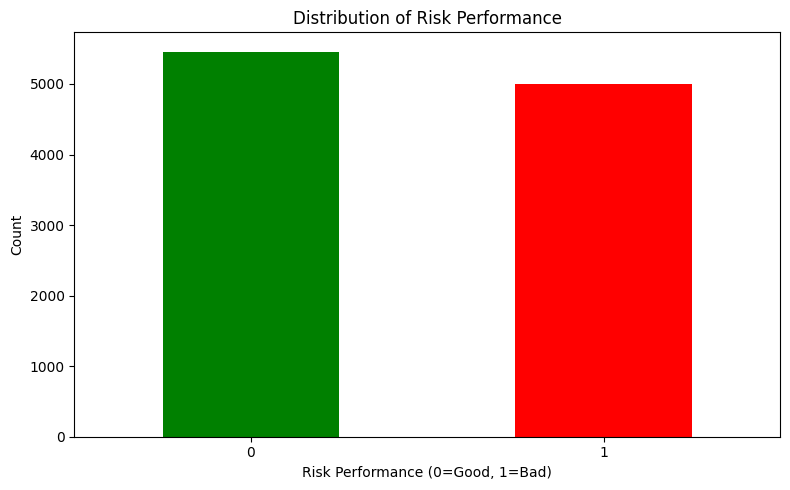

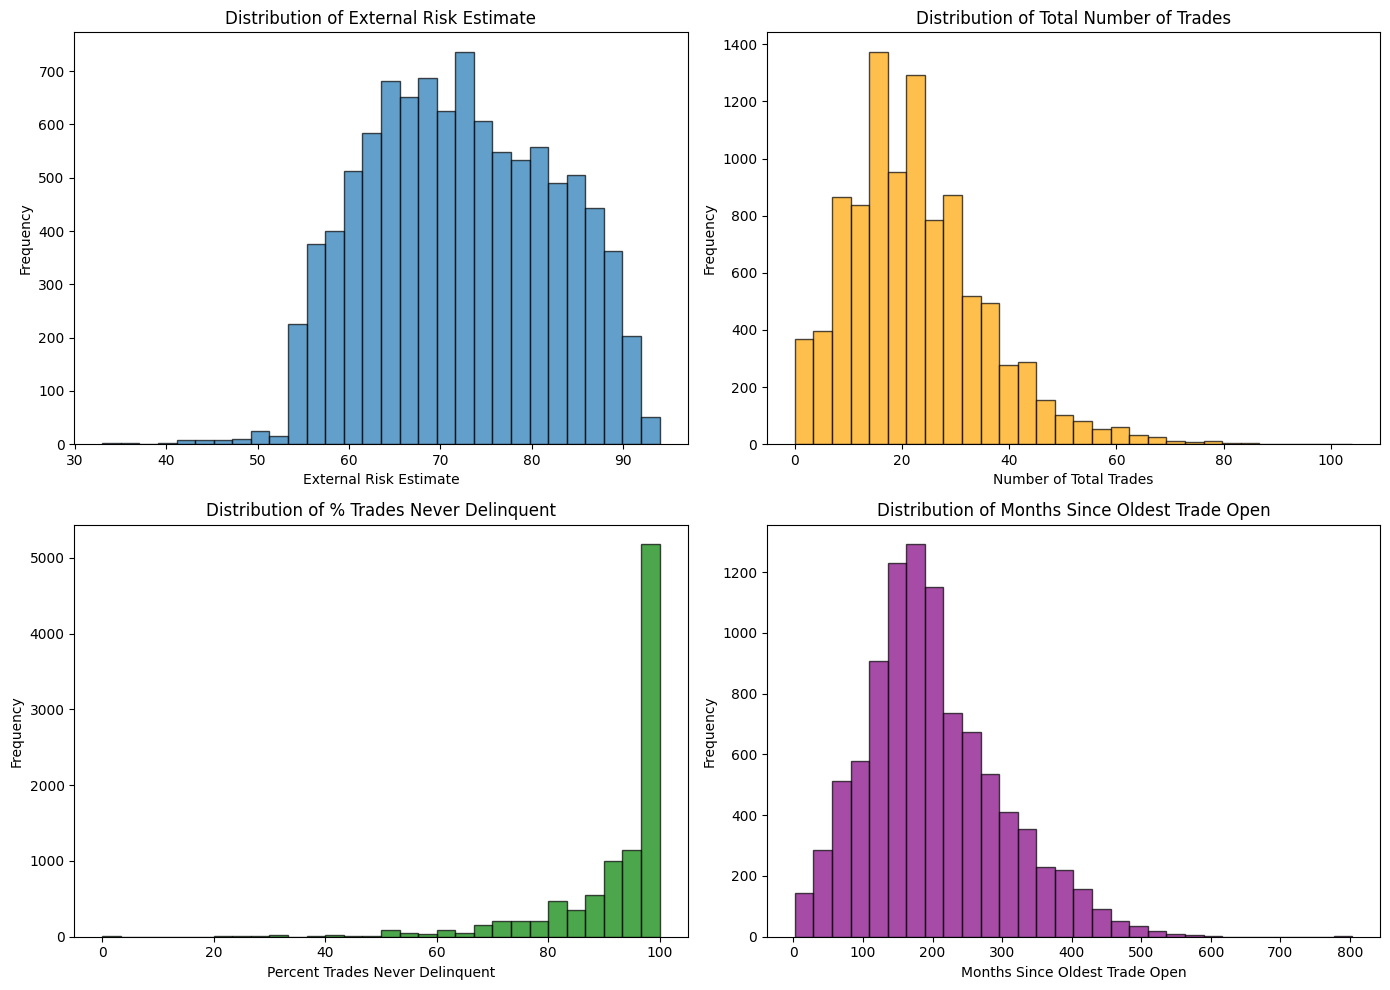

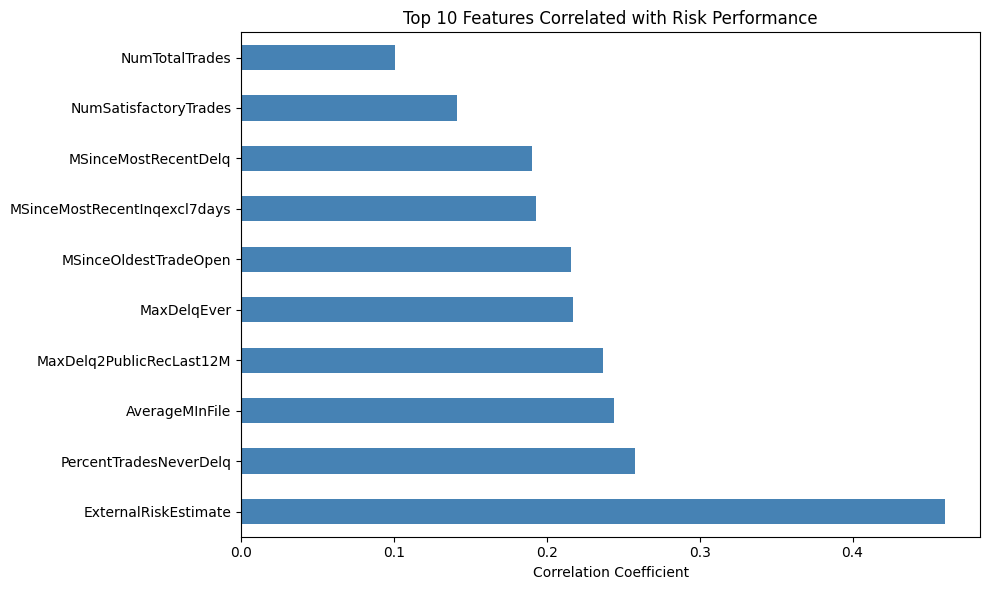

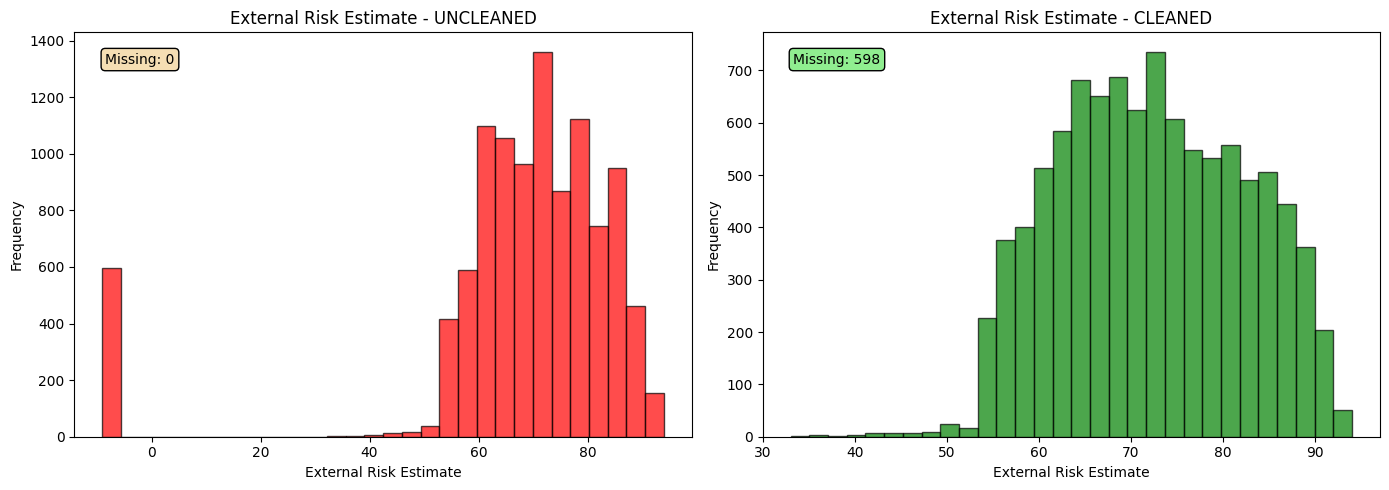

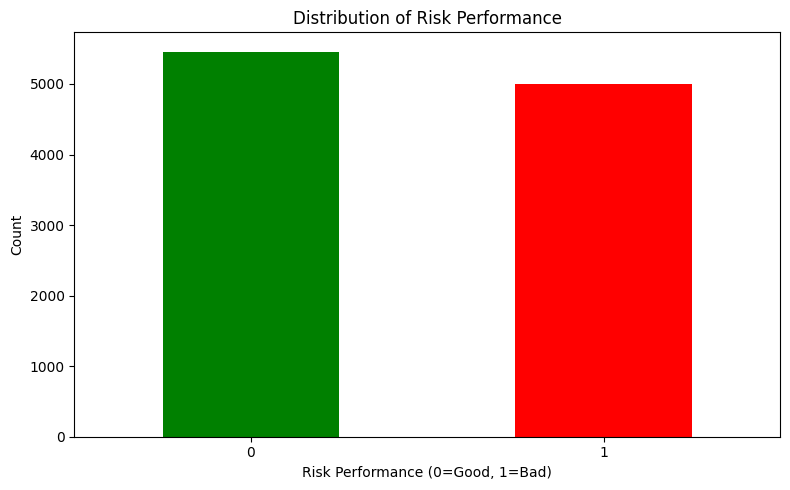

In [16]:
# Target variable distribution
print("Risk Performance Distribution:")
print(df['RiskPerformance'].value_counts())
print(f"\nClass Balance: {df['RiskPerformance'].value_counts(normalize=True)}")

plt.figure(figsize=(8, 5))
df['RiskPerformance'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Risk Performance')
plt.xlabel('Risk Performance (0=Good, 1=Bad)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

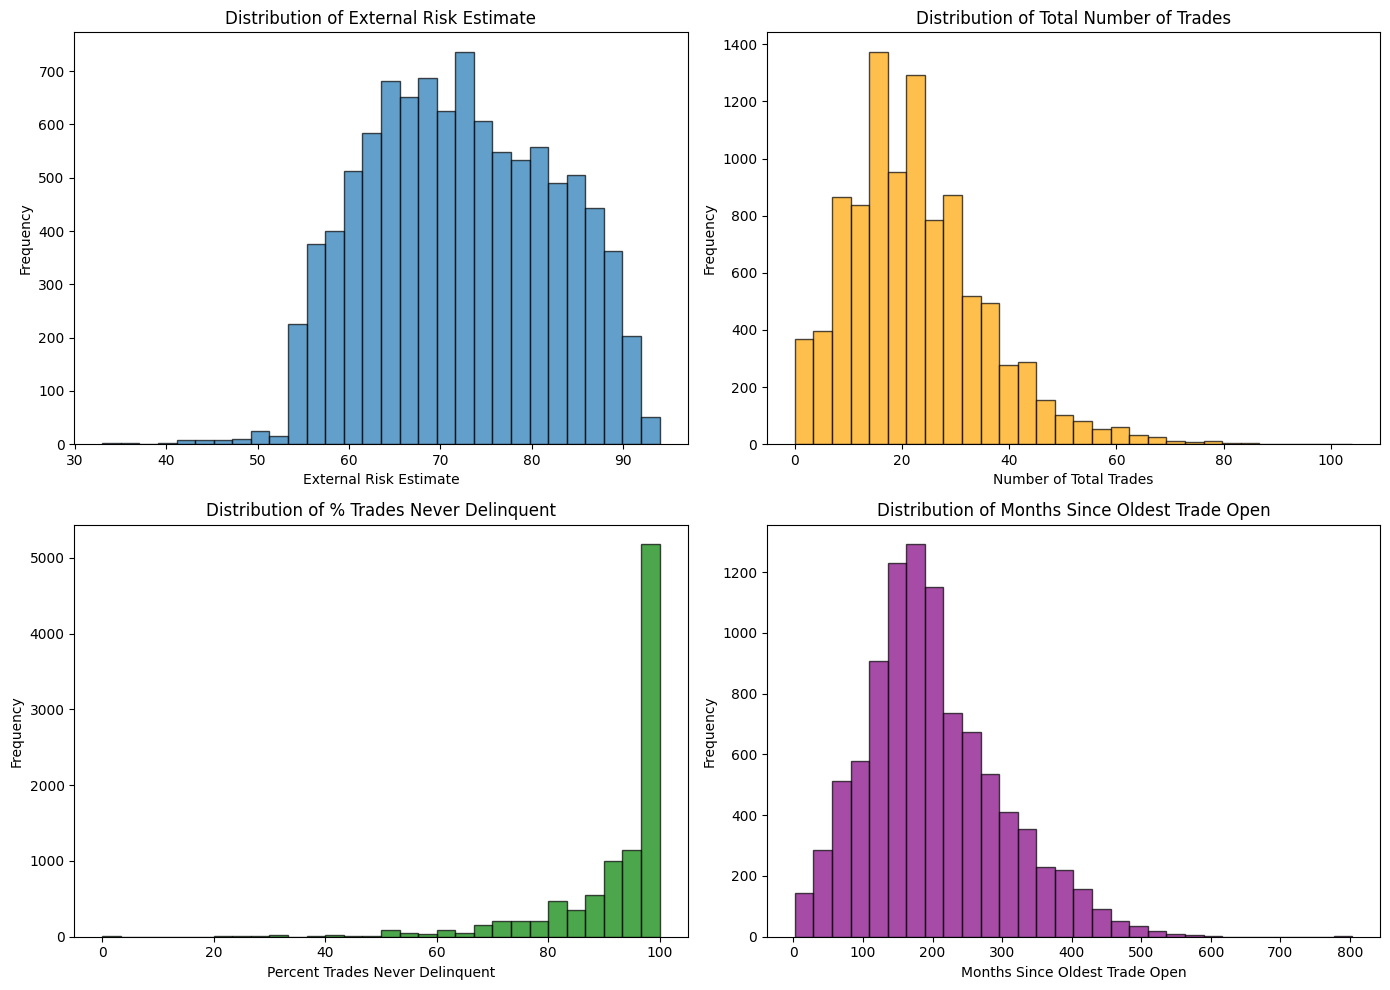

In [18]:
# Distribution of key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ExternalRiskEstimate
axes[0, 0].hist(df['ExternalRiskEstimate'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of External Risk Estimate')
axes[0, 0].set_xlabel('External Risk Estimate')
axes[0, 0].set_ylabel('Frequency')

# NumTotalTrades
axes[0, 1].hist(df['NumTotalTrades'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Distribution of Total Number of Trades')
axes[0, 1].set_xlabel('Number of Total Trades')
axes[0, 1].set_ylabel('Frequency')

# PercentTradesNeverDelq
axes[1, 0].hist(df['PercentTradesNeverDelq'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title('Distribution of % Trades Never Delinquent')
axes[1, 0].set_xlabel('Percent Trades Never Delinquent')
axes[1, 0].set_ylabel('Frequency')

# MSinceOldestTradeOpen
axes[1, 1].hist(df['MSinceOldestTradeOpen'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title('Distribution of Months Since Oldest Trade Open')
axes[1, 1].set_xlabel('Months Since Oldest Trade Open')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
# Correlation analysis with target variable
correlations = df.corr()['RiskPerformance'].sort_values(ascending=False)
print("Top 10 features correlated with Risk Performance:")
print(correlations.head(10))

# Visualize top correlations
plt.figure(figsize=(10, 6))
correlations[1:11].plot(kind='barh', color='steelblue')
plt.title('Top 10 Features Correlated with Risk Performance')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

Top 10 features correlated with Risk Performance:
RiskPerformance                 1.000000
ExternalRiskEstimate            0.460381
PercentTradesNeverDelq          0.257358
AverageMInFile                  0.243869
MaxDelq2PublicRecLast12M        0.236759
MaxDelqEver                     0.216764
MSinceOldestTradeOpen           0.216058
MSinceMostRecentInqexcl7days    0.192686
MSinceMostRecentDelq            0.190301
NumSatisfactoryTrades           0.141092
Name: RiskPerformance, dtype: float64


C:\Users\giris\AppData\Local\Temp\ipykernel_34716\1120790714.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Comparison: Before vs After Cleaning

In [13]:
# Compare dataset sizes and missing values
comparison = pd.DataFrame({
    'Metric': ['Total Rows', 'Total Columns', 'Total Missing Values', 'Missing Value %'],
    'Uncleaned': [
        df_uncleaned.shape[0],
        df_uncleaned.shape[1],
        df_uncleaned.isnull().sum().sum(),
        round(df_uncleaned.isnull().sum().sum() / (df_uncleaned.shape[0] * df_uncleaned.shape[1]) * 100, 2)
    ],
    'Cleaned': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2)
    ]
})
print("Dataset Comparison:")
print(comparison)
print(f"\nRows removed during cleaning: {df_uncleaned.shape[0] - df.shape[0]}")

Dataset Comparison:
                 Metric  Uncleaned   Cleaned
0            Total Rows    10459.0  10459.00
1         Total Columns       24.0     24.00
2  Total Missing Values        0.0  26167.00
3       Missing Value %        0.0     10.42

Rows removed during cleaning: 0


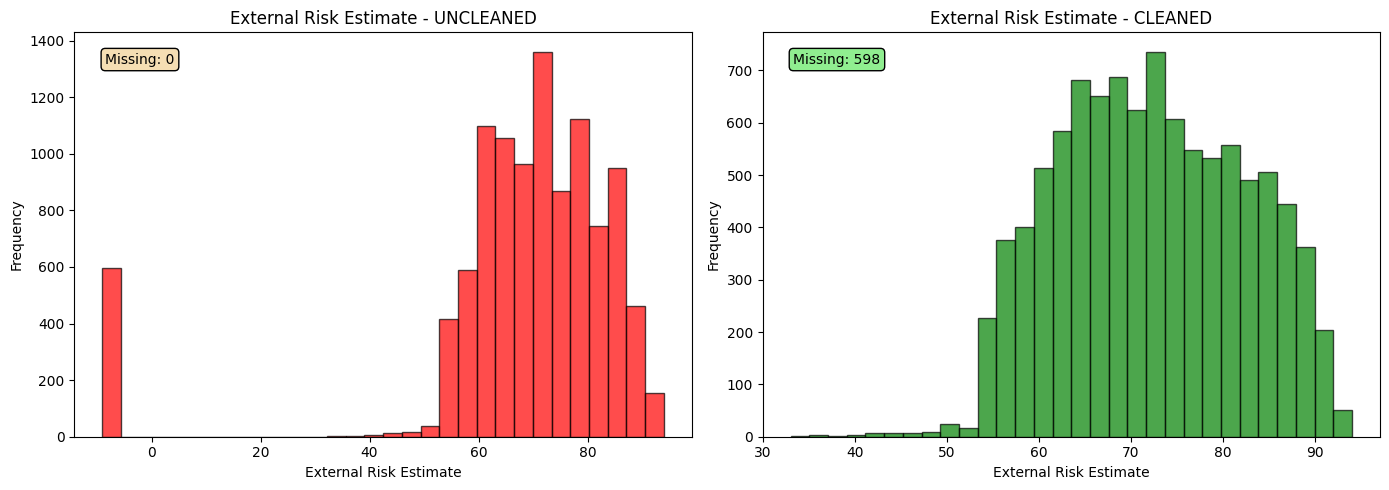

In [17]:
# Compare distribution of a key feature before and after cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ExternalRiskEstimate - Uncleaned
axes[0].hist(df_uncleaned['ExternalRiskEstimate'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='red')
axes[0].set_title('External Risk Estimate - UNCLEANED')
axes[0].set_xlabel('External Risk Estimate')
axes[0].set_ylabel('Frequency')
axes[0].text(0.05, 0.95, f'Missing: {df_uncleaned["ExternalRiskEstimate"].isnull().sum()}', 
             transform=axes[0].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

# ExternalRiskEstimate - Cleaned
axes[1].hist(df['ExternalRiskEstimate'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('External Risk Estimate - CLEANED')
axes[1].set_xlabel('External Risk Estimate')
axes[1].set_ylabel('Frequency')
axes[1].text(0.05, 0.95, f'Missing: {df["ExternalRiskEstimate"].isnull().sum()}', 
             transform=axes[1].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen'))

plt.tight_layout()
plt.show()